In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

isolated_pieces_list = []

def display_detected_fragments(image_path):
    global isolated_pieces_list
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None
    
    # Convert from BGR to RGB for correct Matplotlib color display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    
    # 2. Preprocess to separate paper pieces from the dark background
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Otsu's thresholding to separate white paper from dark gaps
    _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Clean up noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # 3. Find individual contours of each piece of paper
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter out tiny noise (keep only fragments larger than 1% of the total image area)
    min_area = (h * w) * 0.009
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]
    
    print(f"Detected {len(fragments)} distinct paper fragments.")
    
    highlighted_img = img_rgb.copy()
    num_fragments = len(fragments)
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols
    
    plt.figure(figsize=(15, rows * 4))
    
    for idx, contour in enumerate(fragments):
        cv2.drawContours(highlighted_img, [contour], -1, (255, 0, 0), 4) # Blue outline
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(highlighted_img, f"ID: {idx}", (x + 10, y + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")
    
    temporary_storage = []
    # Plot remaining subplots: Individual cropped pieces
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Isolate the current piece
        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        
        # Crop to its bounding box boundaries
        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y:y+ph, x:x+pw]
        
        # CRITICAL FIX: Save the cropped image alongside its structural (x, y) origin coordinates
        temporary_storage.append({
            'img': cropped_piece,
            'orig_x': x,
            'orig_y': y
        })
        
    plt.tight_layout()
    plt.show()
    
    return temporary_storage, w

# --- SORTING FUNCTION ---

def sort_pieces_bottom_up_column_wise(fragment_data, total_width, col_width_ratio=0.25):
    """
    Groups fragments into logical vertical columns based on their true origin X coordinate.
    Sorts columns from Left to Right, and fragments inside each column from Bottom to Top.
    """
    column_band_width = total_width * col_width_ratio
    columns = {}
    
    # Group pieces into vertical column buckets
    for entry in fragment_data:
        col_idx = int(entry['orig_x'] // column_band_width)
        if col_idx not in columns:
            columns[col_idx] = []
        columns[col_idx].append(entry)
        
    sorted_pieces = []
    
    # Iterate through column index structures sorted Left to Right
    for col in sorted(columns.keys()):
        column_group = columns[col]
        
        # Sort column elements from Bottom to Top (descending order of structural Y)
        column_group.sort(key=lambda item: item['orig_y'], reverse=True)
        
        for item in column_group:
            sorted_pieces.append(item['img'])
            
    return sorted_pieces

# --- STITCHING CORE LOGIC ---

def get_thresh(img):
    return cv2.threshold(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY)[1]

def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y:-min_y+hA, -min_x:-min_x+wA][threshA > 0] = imgA[threshA > 0]
    canvas[dy-min_y:dy-min_y+hB, dx-min_x:dx-min_x+wB][threshB > 0] = imgB[threshB > 0]
    return canvas

def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (int(p2[0].max()) - int(p3[0].max())) if ref == "bottom" else (int(p2[0].min()) - int(p3[0].min()))
    
    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {r: np.max(x2[y2 == r]) for r in range(np.min(p2[0]), np.max(p2[0]) + 1) if len(x2[y2 == r]) > 0}
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {r: np.min(x3[y3 == r]) for r in range(np.min(p3[0]), np.max(p3[0]) + 1) if len(x3[y3 == r]) > 0}
    
    dx = int(np.percentile([b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90))
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)

def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)
    
    dx = (np.min(x0) if side == "left" else np.max(x0)) - (np.min(x1) if side == "left" else np.max(x1))
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}
    
    dy = int(np.percentile([bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92))
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)

def ad_stitch(img_base, img_patch):
    m_b = ((cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)
    m_p = ((cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15) * 255).astype(np.uint8)
    
    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out, dist_in = cv2.distanceTransform(~m_b, cv2.DIST_L2, 5), cv2.distanceTransform(m_b, cv2.DIST_L2, 5)
    
    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float('inf')
    
    for dy in range(-int(h_b * 0.8), int(h_b * 0.8)):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue
                
            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]
            
            touching = np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            deep = np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            score = -touching + (4.0 * deep)
            
            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    canvas = np.zeros((max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox), 3), dtype=np.uint8)
    canvas[oy:oy+h_b, ox:ox+w_b] = img_base
    canvas[best_dy+oy : best_dy+oy+h_p, best_dx+ox : best_dx+ox+w_p][m_p == 255] = img_patch[m_p == 255]
    return canvas

def detect_flat_edges(piece1, piece2):
    sides = []
    for img in [piece1, piece2]:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
        _, thresh = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
        y, x = np.where(thresh == 255)
        if len(y) == 0:
            sides.append(None)
            continue
            
        ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
        w, h = xmax - xmin + 1, ymax - ymin + 1
        mw, mh = int(w * 0.1), int(h * 0.1)
        
        flatness = {}
        configs = [
            ("top", x, y, xmin, xmax, mw, w, np.min),
            ("bottom", x, y, xmin, xmax, mw, w, np.max),
            ("left", y, x, ymin, ymax, mh, h, np.min),
            ("right", y, x, ymin, ymax, mh, h, np.max)
        ]
        
        for name, axis, target, start, end, margin, size, func in configs:
            profile = [func(target[axis == val]) for val in range(start + margin, end - margin + 1) if np.any(axis == val)]
            if len(profile) > 0.5 * size:
                flatness[name] = np.std(profile)

        detected_side = None
        if flatness:
            best_side, best_std = min(flatness.items(), key=lambda x: x[1])
            if best_std < 1.5:
                detected_side = best_side
        sides.append(detected_side)
    return sides[0], sides[1]

def display_final_canvas(raw_fragment_metadata, image_width):
    if raw_fragment_metadata:
        # Perform column-wise bottom-to-top reverse sorting strategy
        isolated_pieces_list = sort_pieces_bottom_up_column_wise(raw_fragment_metadata, image_width)
        
        positions = isolated_pieces_list
        can = positions[0]

        for i in range(1, len(positions)):
            next_piece = positions[i]
            side1, side2 = detect_flat_edges(can, next_piece)
            
            if side1 == side2 and side1 is not None:
                if side1 in ['bottom', 'top']:
                    can = stitch_by_edge(can, next_piece, ref=side1)
                elif side1 in ['left', 'right']:
                    can = stitch_by_margin(can, next_piece, side=side1)
            else:
                can = ad_stitch(can, next_piece)
                
            plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
            plt.show()

        plt.figure(figsize=(10,10))
        plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
        plt.title("Final Column-Sorted Reconstruction Canvas")
        plt.axis("off")
        plt.show()
    
raw_fragment_metadata, image_width = display_detected_fragments(r'D:\PythonProject1\Intern\Images\img79.jpeg')
display_final_canvas(raw_fragment_metadata, image_width)

if raw_fragment_metadata:
    # Perform column-wise bottom-to-top reverse sorting strategy
    isolated_pieces_list = sort_pieces_bottom_up_column_wise(raw_fragment_metadata, image_width)
    
    positions = isolated_pieces_list
    can = positions[0]

    for i in range(1, len(positions)):
        next_piece = positions[i]
        side1, side2 = detect_flat_edges(can, next_piece)
        
        if side1 == side2 and side1 is not None:
            if side1 in ['bottom', 'top']:
                can = stitch_by_edge(can, next_piece, ref=side1)
            elif side1 in ['left', 'right']:
                can = stitch_by_margin(can, next_piece, side=side1)
        else:
            can = ad_stitch(can, next_piece)
            
        plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
        plt.show()

    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
    plt.title("Final Column-Sorted Reconstruction Canvas")
    plt.axis("off")
    plt.show()

Detected 7 distinct paper fragments.


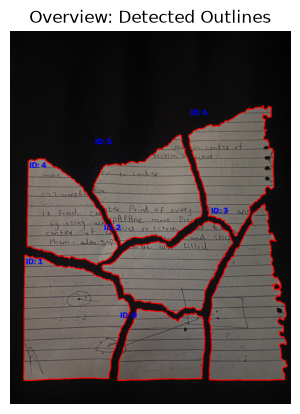

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

isolated_pieces_list = []


def display_detected_fragments(image_path):
    global isolated_pieces_list
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None, None

    # Convert from BGR to RGB for correct Matplotlib color display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape

    # 2. Preprocess to separate paper pieces from the dark background
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Otsu's thresholding to separate white paper from dark gaps
    _, thresh = cv2.threshold(
        gray, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Clean up noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # 3. Find individual contours of each piece of paper
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Filter out tiny noise (keep only fragments larger than 0.9% of total image area)
    min_area = (h * w) * 0.009
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]

    print(f"Detected {len(fragments)} distinct paper fragments.")

    highlighted_img = img_rgb.copy()
    num_fragments = len(fragments)
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols

    plt.figure(figsize=(15, rows * 4))

    for idx, contour in enumerate(fragments):
        cv2.drawContours(
            highlighted_img, [contour], -1, (255, 0, 0), 4
        )  # Blue outline
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(
            highlighted_img,
            f"ID: {idx}",
            (x + 10, y + 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3,
        )

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")

    temporary_storage = []
    # Plot remaining subplots: Individual cropped pieces
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

        # Isolate the current piece
        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

        # Crop to its bounding box boundaries
        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y : y + ph, x : x + pw]

        # Convert back to BGR so stitching functions get standard OpenCV images
        cropped_bgr = cv2.cvtColor(cropped_piece, cv2.COLOR_RGB2BGR)

        temporary_storage.append(
            {"img": cropped_bgr, "orig_x": x, "orig_y": y}
        )

    plt.tight_layout()
    plt.show()

    return temporary_storage, w


# --- STITCHING CORE LOGIC ---


def get_thresh(img):
    return cv2.threshold(
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY
    )[1]


def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y : -min_y + hA, -min_x : -min_x + wA][threshA > 0] = imgA[
        threshA > 0
    ]
    canvas[dy - min_y : dy - min_y + hB, dx - min_x : dx - min_x + wB][
        threshB > 0
    ] = imgB[threshB > 0]
    return canvas


def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (
        (int(p2[0].max()) - int(p3[0].max()))
        if ref == "bottom"
        else (int(p2[0].min()) - int(p3[0].min()))
    )

    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {
        r: np.max(x2[y2 == r])
        for r in range(np.min(p2[0]), np.max(p2[0]) + 1)
        if len(x2[y2 == r]) > 0
    }
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {
        r: np.min(x3[y3 == r])
        for r in range(np.min(p3[0]), np.max(p3[0]) + 1)
        if len(x3[y3 == r]) > 0
    }

    dx = int(
        np.percentile(
            [b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90
        )
    )
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)


def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)

    dx = (np.min(x0) if side == "left" else np.max(x0)) - (
        np.min(x1) if side == "left" else np.max(x1)
    )
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}

    dy = int(
        np.percentile(
            [bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92
        )
    )
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)


def ad_stitch(img_base, img_patch):
    m_b = (
        (cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15) * 255
    ).astype(np.uint8)
    m_p = (
        (cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15) * 255
    ).astype(np.uint8)

    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out, dist_in = cv2.distanceTransform(
        ~m_b, cv2.DIST_L2, 5
    ), cv2.distanceTransform(m_b, cv2.DIST_L2, 5)

    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float("inf")

    for dy in range(-int(h_b * 0.8), int(h_b * 0.8)):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue

            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]

            touching = (
                np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            )
            deep = np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            score = -touching + (4.0 * deep)

            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    canvas = np.zeros(
        (max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox), 3),
        dtype=np.uint8,
    )
    canvas[oy : oy + h_b, ox : ox + w_b] = img_base
    canvas[
        best_dy + oy : best_dy + oy + h_p, best_dx + ox : best_dx + ox + w_p
    ][m_p == 255] = img_patch[m_p == 255]
    return canvas


def detect_flat_edges(piece1, piece2):
    sides = []
    for img in [piece1, piece2]:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        _, thresh = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
        y, x = np.where(thresh == 255)
        if len(y) == 0:
            sides.append(None)
            continue

        ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
        w, h = xmax - xmin + 1, ymax - ymin + 1
        mw, mh = int(w * 0.1), int(h * 0.1)

        flatness = {}
        configs = [
            ("top", x, y, xmin, xmax, mw, w, np.min),
            ("bottom", x, y, xmin, xmax, mw, w, np.max),
            ("left", y, x, ymin, ymax, mh, h, np.min),
            ("right", y, x, ymin, ymax, mh, h, np.max),
        ]

        for name, axis, target, start, end, margin, size, func in configs:
            profile = [
                func(target[axis == val])
                for val in range(start + margin, end - margin + 1)
                if np.any(axis == val)
            ]
            if len(profile) > 0.5 * size:
                flatness[name] = np.std(profile)

        detected_side = None
        if flatness:
            best_side, best_std = min(flatness.items(), key=lambda x: x[1])
            if best_std < 1.5:
                detected_side = best_side
        sides.append(detected_side)
    return sides[0], sides[1]


def display_final_canvas(raw_fragment_metadata):
    if not raw_fragment_metadata:
        return

    # Extract image pieces directly without any column sorting
    positions = [item["img"] for item in raw_fragment_metadata]
    can = positions[0]

    # for i in range(1, len(positions)):
    #     next_piece = positions[i]
    #     side1, side2 = detect_flat_edges(can, next_piece)
        
    #     if side1 == side2 and side1 is not None:
    #         if side1 in ["bottom", "top"]:
    #             can = stitch_by_edge(can, next_piece, ref=side1)
    #         elif side1 in ["left", "right"]:
    #             can = stitch_by_margin(can, next_piece, side=side1)
    #     else:
    #         can = ad_stitch(can, next_piece)

    #     plt.figure()
    #     plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
    #     plt.axis("off")
    #     plt.show()
    
    can=stitch_by_edge(positions[1],can,ref='bottom')
    can=stitch_by_edge(can,positions[3],ref='bottom')
    can= stitch_by_margin( positions[4],can, side='left')
    
    can=ad_stitch(can,positions[2])
    plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
    plt.title("Final Reconstruction Canvas")
    plt.axis("off")
    plt.show()
    can=ad_stitch(can,positions[5])
    can=ad_stitch(can,positions[6])

    plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
    plt.title("Final Reconstruction Canvas")
    plt.axis("off")
    plt.show()


raw_fragment_metadata, image_width = display_detected_fragments(
    r"D:\PythonProject1\Intern\Images\img158.jpeg"
)
display_final_canvas(raw_fragment_metadata)
